# 1. Download Gaze Sweep Data (Align & EGViT)
This cell connects to the W&B project `PCS_ET_v22` and fetches the results for two separate sweeps:
1. **Align Mode (``)**: Extracts the `attn_w` hyperparameter.
2. **EGViT Mode (`7658e92p`)**: Extracts the `egvit_keep_ratio` hyperparameter.

For both sweeps, it scans the training history to find the peak `accuracy_validation` and saves the data to respective CSV files (`align_attn_w_results.csv` and `egvit_keep_ratio_results.csv`).

In [1]:
import os
import wandb
import pandas as pd

# 1. Setup API
api = wandb.Api()
entity = "luis-perdigao-instituto-superior-t-cnico"
project = "PCS_ET_v22"

# Create results folder
os.makedirs("results", exist_ok=True)

# ---------------------------------------------------------
# A. Fetch Align Sweeps (attn_w & attention_mode)
# ---------------------------------------------------------
sweep_ids_align = ["h5cz7vzu", "87v3i01r", "5qhe8l0q", "nlmta2n8", "r3ejtmt3", "81crnv1z"]
print("Fetching runs from Align sweeps...")

data_list_align = []

for sweep_id_align in sweep_ids_align:
    print(f"  -> Scanning sweep: {sweep_id_align}...")
    try:
        sweep_align = api.sweep(f"{entity}/{project}/{sweep_id_align}")
        runs_align = sweep_align.runs
        print(f"     Found {len(runs_align)} runs. Processing history...")
        
        for run in runs_align:
            config = {k: v for k, v in run.config.items() if not k.startswith('_')}
            history = pd.DataFrame(run.scan_history(keys=["accuracy_validation"]))
            
            if not history.empty and "accuracy_validation" in history.columns:
                best_val_acc = history["accuracy_validation"].max()
            else:
                best_val_acc = run.summary.get("max_accuracy_validation", run.summary.get("accuracy_validation", None))

            attn_w = config.get("attn_w", None)
            # NEW: Extract attention_mode
            attn_mode = config.get("attention_mode", "unknown") 
            seed = config.get("seed", pd.NA)

            if attn_w is not None and best_val_acc is not None:
                data_list_align.append({
                    "sweep_id": sweep_id_align,
                    "run_name": run.name,
                    "backbone": config.get("backbone", "unknown"),
                    "attn_w": attn_w,
                    "attention_mode": attn_mode, # NEW: Save it to the row
                    "seed": seed,
                    "val_rank_acc": best_val_acc
                })
    except Exception as e:
        print(f"     Error accessing Align sweep {sweep_id_align}: {e}")

df_align = pd.DataFrame(data_list_align)
df_align.to_csv("results/align_attn_w_results.csv", index=False)
print(f"Saved {len(df_align)} total Align runs to 'results/align_attn_w_results.csv'.\n")


# ---------------------------------------------------------
# B. Fetch EGViT Sweep (egvit_keep_ratio)
# ---------------------------------------------------------
sweep_id_egvit = "7658e92p"
print(f"Fetching runs from EGViT sweep: {sweep_id_egvit}...")

try:
    sweep_egvit = api.sweep(f"{entity}/{project}/{sweep_id_egvit}")
    runs_egvit = sweep_egvit.runs
    print(f"  Found {len(runs_egvit)} runs. Processing history...")
    
    data_list_egvit = []
    for run in runs_egvit:
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        history = pd.DataFrame(run.scan_history(keys=["accuracy_validation"]))
        
        if not history.empty and "accuracy_validation" in history.columns:
            best_val_acc = history["accuracy_validation"].max()
        else:
            best_val_acc = run.summary.get("max_accuracy_validation", run.summary.get("accuracy_validation", None))

        keep_ratio = config.get("egvit_keep_ratio", config.get("keep_ratio", None))
        seed = config.get("seed", pd.NA)

        if keep_ratio is not None and best_val_acc is not None:
            data_list_egvit.append({
                "run_name": run.name,
                "backbone": config.get("backbone", "unknown"),
                "egvit_keep_ratio": keep_ratio,
                "seed": seed,
                "val_rank_acc": best_val_acc
            })

    df_egvit = pd.DataFrame(data_list_egvit)
    df_egvit.to_csv("results/egvit_keep_ratio_results.csv", index=False)
    print(f"  -> Saved {len(df_egvit)} runs to 'results/egvit_keep_ratio_results.csv'.\n")

except Exception as e:
    print(f"  -> Error accessing EGViT sweep {sweep_id_egvit}: {e}\n")

print("All data downloads complete!")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luis-perdigao (luis-perdigao-instituto-superior-t-cnico) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetching runs from Align sweeps...
  -> Scanning sweep: h5cz7vzu...
     Found 60 runs. Processing history...
  -> Scanning sweep: 87v3i01r...
     Found 120 runs. Processing history...
  -> Scanning sweep: 5qhe8l0q...
     Found 60 runs. Processing history...
  -> Scanning sweep: nlmta2n8...
     Found 10 runs. Processing history...
  -> Scanning sweep: r3ejtmt3...
     Found 60 runs. Processing history...
  -> Scanning sweep: 81crnv1z...
     Found 60 runs. Processing history...
Saved 360 total Align runs to 'results/align_attn_w_results.csv'.

Fetching runs from EGViT sweep: 7658e92p...
  Found 13 runs. Processing history...
  -> Saved 13 runs to 'results/egvit_keep_ratio_results.csv'.

All data downloads complete!


# 2. Analyze and Plot Align Mode (attn_w)
This cell reads `align_attn_w_results.csv` and generates a line plot showing Validation Accuracy against the Attention Weight (`attn_w`) for each backbone.

The best configuration for each backbone is highlighted, and the best average `attn_w` is shown in the legend.

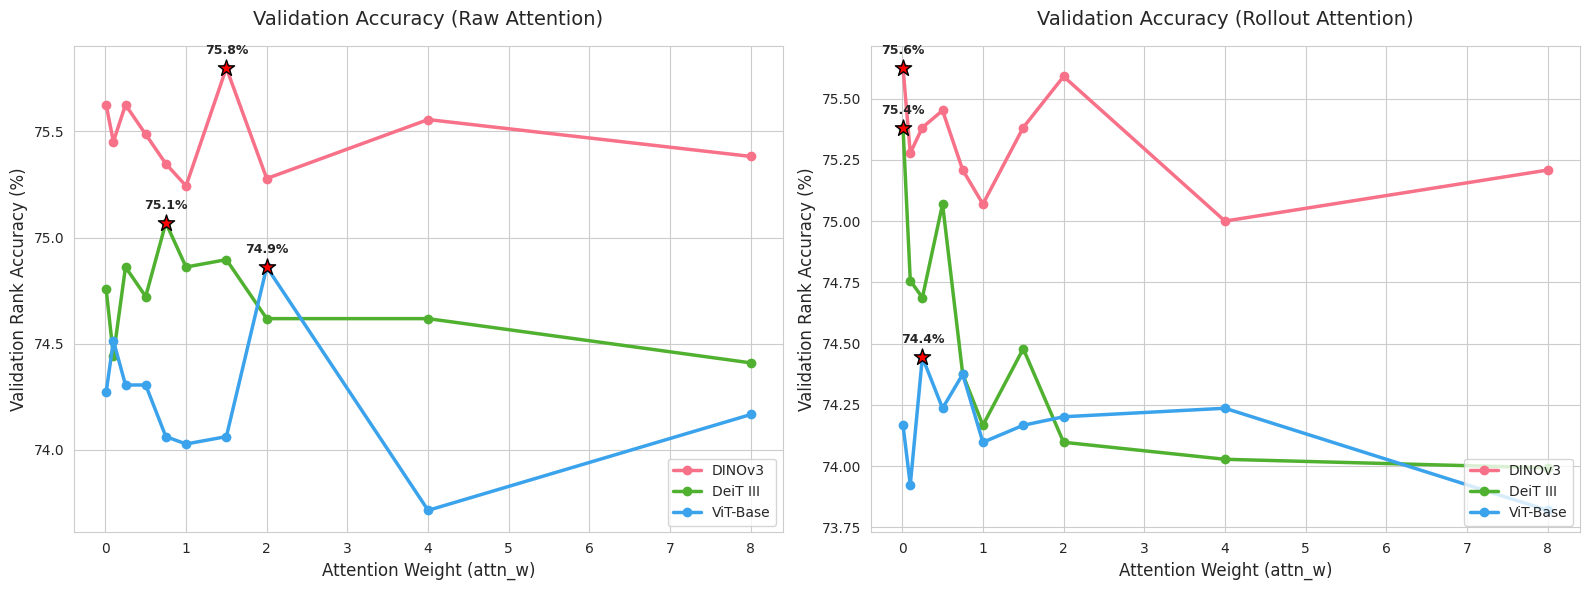

Plots saved successfully as 'images/align_attn_w_plots_split.png'!

--------------------------------------------------
🏆 BEST ATTENTION WEIGHTS SUMMARY 🏆
--------------------------------------------------

--- RAW ATTENTION ---
DINOv3       -> Best attn_w:  1.5  (Accuracy: 75.80%)
DeiT III     -> Best attn_w: 0.75  (Accuracy: 75.07%)
ViT-Base     -> Best attn_w:  2.0  (Accuracy: 74.86%)

--- ROLLOUT ATTENTION ---
DINOv3       -> Best attn_w: 0.01  (Accuracy: 75.62%)
DeiT III     -> Best attn_w: 0.01  (Accuracy: 75.38%)
ViT-Base     -> Best attn_w: 0.25  (Accuracy: 74.44%)


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
try:
    df = pd.read_csv("results/align_attn_w_results.csv")
except FileNotFoundError:
    print("File 'results/align_attn_w_results.csv' not found. Please run Cell 1 first.")
    df = pd.DataFrame()

if not df.empty:
    # Clean backbone names
    backbone_map = {
        'dinov3_vitb16': 'DINOv3',
        'vit_base_patch16_224': 'ViT-Base',
        'deit3_base_patch16_224': 'DeiT III',
        'vit_base_patch16_clip_224': 'CLIP',
        'clip': 'CLIP',
        'vit_small': 'ViT-Small'
    }
    df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])

    # Drop rows where attn_w is 25 or 100
    df = df[~df['attn_w'].isin([25, 100])]

    # Aggregate: Group by backbone AND attention_mode AND attn_w
    df_agg = df.groupby(['backbone', 'attention_mode', 'attn_w'], as_index=False)['val_rank_acc'].mean()

    # Plotting Setup (1 row, 2 columns for side-by-side plots)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_style("whitegrid")

    backbones = df_agg['backbone'].unique()
    colors = sns.color_palette("husl", len(backbones))

    modes = ['raw', 'rollout']
    titles = ["Validation Accuracy (Raw Attention)", "Validation Accuracy (Rollout Attention)"]

    for ax, mode, title in zip(axes, modes, titles):
        # Filter data for just this mode
        mode_subset = df_agg[df_agg['attention_mode'] == mode]
        
        # If a mode is missing from the data, skip gracefully
        if mode_subset.empty:
            ax.set_title(f"{title}\n(No data found)", fontsize=14)
            continue

        for i, backbone in enumerate(backbones):
            subset = mode_subset[mode_subset['backbone'] == backbone].sort_values('attn_w')
            
            if subset.empty:
                continue 
            
            # Line plot
            ax.plot(subset['attn_w'], subset['val_rank_acc'] * 100, marker='o', 
                    label=f"{backbone}", color=colors[i], linewidth=2.5, markersize=6)
            
            # Highlight highest accuracy for this specific line
            best_idx = subset['val_rank_acc'].idxmax()
            best_row = subset.loc[best_idx]
            
            ax.scatter(best_row['attn_w'], best_row['val_rank_acc'] * 100, 
                       color='red', s=150, zorder=5, edgecolor='black', marker='*')
            
            # Annotate the max point
            ax.annotate(f"{best_row['val_rank_acc']*100:.1f}%", 
                        (best_row['attn_w'], best_row['val_rank_acc'] * 100),
                        textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, weight='bold')

        # Aesthetics
        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel("Attention Weight (attn_w)", fontsize=12)
        ax.set_ylabel("Validation Rank Accuracy (%)", fontsize=12)
        ax.legend(loc="lower right", fontsize=10)

    plt.tight_layout()

    os.makedirs("images", exist_ok=True)
    image_path = "images/align_attn_w_plots_split.png"
    plt.savefig(image_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Plots saved successfully as '{image_path}'!\n")

    # ==========================================
    # PRINT BEST VALUES PER BACKBONE AND MODE
    # ==========================================
    print("-" * 50)
    print("🏆 BEST ATTENTION WEIGHTS SUMMARY 🏆")
    print("-" * 50)

    for mode in modes:
        mode_subset = df_agg[df_agg['attention_mode'] == mode]
        if mode_subset.empty:
            continue
            
        print(f"\n--- {mode.upper()} ATTENTION ---")
        for backbone in backbones:
            subset = mode_subset[mode_subset['backbone'] == backbone]
            if subset.empty:
                continue
            
            # Find the row with the maximum accuracy
            best_idx = subset['val_rank_acc'].idxmax()
            best_row = subset.loc[best_idx]
            
            print(f"{backbone:<12} -> Best attn_w: {best_row['attn_w']:>4}  (Accuracy: {best_row['val_rank_acc']*100:.2f}%)")

# 3. Analyze and Plot EGViT Mode (egvit_keep_ratio)
This cell reads `egvit_keep_ratio_results.csv` and generates a line plot showing Validation Accuracy against the Keep Ratio (`egvit_keep_ratio`) for each backbone.

The best configuration for each backbone is highlighted, and the best average keep ratio is shown in the legend.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Load Data
try:
    df = pd.read_csv("egvit_keep_ratio_results.csv")
except FileNotFoundError:
    print("File 'egvit_keep_ratio_results.csv' not found. Please run Cell 1 first.")
    df = pd.DataFrame()

if not df.empty:
    # Clean backbone names
    backbone_map = {
        'dinov3_vitb16': 'DINOv3',
        'vit_base_patch16_224': 'ViT-Base',
        'deit3_base_patch16_224': 'DeiT III',
        'vit_small': 'ViT-Small'
    }
    df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])

    # Aggregate
    df_agg = df.groupby(['backbone', 'egvit_keep_ratio'], as_index=False)['val_rank_acc'].mean()

    # Find the best average keep ratio
    avg_per_hp = df_agg.groupby('egvit_keep_ratio')['val_rank_acc'].mean()
    best_avg_hp = avg_per_hp.idxmax()
    best_avg_val = avg_per_hp.max()

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    backbones = df_agg['backbone'].unique()
    colors = sns.color_palette("husl", len(backbones))

    for i, backbone in enumerate(backbones):
        subset = df_agg[df_agg['backbone'] == backbone].sort_values('egvit_keep_ratio')
        
        plt.plot(subset['egvit_keep_ratio'], subset['val_rank_acc'] * 100, marker='o', 
                 label=f"{backbone}", color=colors[i], linewidth=2.5, markersize=6)
        
        # Highlight highest accuracy
        best_idx = subset['val_rank_acc'].idxmax()
        best_row = subset.loc[best_idx]
        
        plt.scatter(best_row['egvit_keep_ratio'], best_row['val_rank_acc'] * 100, 
                    color='red', s=200, zorder=5, edgecolor='black', marker='*')
        
        plt.annotate(f"{best_row['val_rank_acc']*100:.1f}%", 
                     (best_row['egvit_keep_ratio'], best_row['val_rank_acc'] * 100),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, weight='bold')

    plt.title("Validation Accuracy vs. Keep Ratio (EGViT Mode)", fontsize=14, pad=15)
    plt.xlabel("Keep Ratio (egvit_keep_ratio)", fontsize=12)
    plt.ylabel("Validation Rank Accuracy (%)", fontsize=12)

    # Custom Legend
    handles, labels = plt.gca().get_legend_handles_labels()
    blank_patch = mpatches.Patch(color='none', label=' ')
    best_avg_patch = mpatches.Patch(color='none', label=f'🏆 Best Avg Keep Ratio: {best_avg_hp} ({best_avg_val*100:.1f}%)')

    handles.extend([blank_patch, best_avg_patch])
    labels.extend([blank_patch.get_label(), best_avg_patch.get_label()])

    plt.legend(handles=handles, labels=labels, title="Backbones", loc="lower right", fontsize=10)
    plt.tight_layout()

    plt.savefig("egvit_keep_ratio_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot saved successfully as 'egvit_keep_ratio_plot.png'!")

File 'egvit_keep_ratio_results.csv' not found. Please run Cell 1 first.
